In [ ]:
import tensorflow as tf
print(tf.__version__) #checking tensorflow version
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus)) # check if the GPU is available

if gpus:
    print("GPU Details:", gpus)
else:
    print("No GPU detected. TensorFlow is running on CPU.")

2026-08-03 20:32:58.639687: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-03 20:32:59.117582: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-03 20:33:03.391648: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2.20.0
Num GPUs Available:  1
GPU Details: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
""""external libaries import configuration"""
import tensorflow as tf
from tensorflow import keras # type: ignore
from tensorflow.keras import layers  # type: ignore

import numpy as np
import matplotlib.pyplot as plt

import os
import pathlib

In [ ]:
img_size = (160,160) # All images will be resized to 160x160
batch_size = 32
SEED = 42  # MUST be identical for both subsets — this is what makes the split disjoint

# train and val are carved out of the same directory, so they share validation_split + seed
train_ds = tf.keras.utils.image_dataset_from_directory(
    'data/train',  # This is the target directory
    validation_split=0.1,
    subset="training",
    seed=SEED,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='binary'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    validation_split=0.1,
    subset="validation",
    seed=SEED,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary"
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/test",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="binary",
    shuffle=False
)

# guard against the split silently regressing (e.g. mismatched seeds)
overlap = set(train_ds.file_paths) & set(val_ds.file_paths)
assert not overlap, f"train/val leakage: {len(overlap)} shared images"
print(f"train: {len(train_ds.file_paths)}  val: {len(val_ds.file_paths)}  test: {len(test_ds.file_paths)}")

class_names = train_ds.class_names
print(class_names)  # ['cat', 'dog']

2026-08-03 20:33:21.256245: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


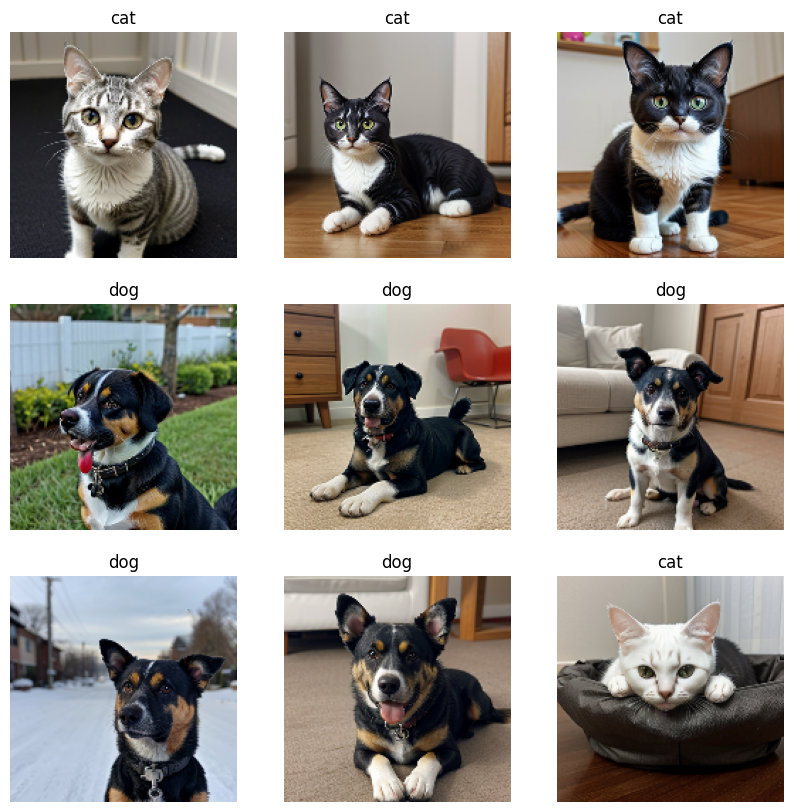

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): #Grabs only the first batch 
                                       # from the dataset. If your batch size is 32, this single step pulls 32 images and 32 labels.
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

In [ ]:
#Apply Vgg16 preprocessing
# NOTE: this rebinds the dataset names in place, so cell 2 must be re-run
# before re-running this cell (otherwise preprocessing gets applied twice).
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y))   # was assigned to `validation_ds`, which nothing used
test_ds  = test_ds.map(lambda x, y: (preprocess_input(x), y))


In [ ]:
Autotune = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=Autotune)
test_ds = test_ds.cache().prefetch(buffer_size=Autotune)
val_ds = val_ds.cache().prefetch(buffer_size=Autotune)

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
from tensorflow.keras.applications import VGG16
base_model = VGG16(
    input_shape=img_size + (3,),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

In [ ]:
inputs = tf.keras.Input(shape=img_size + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 5, 5, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
EPOCHS = 30


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    
)

Epoch 1/30


2026-08-03 20:33:42.167033: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:28: Filling up shuffle buffer (this may take a while): 11 of 1000
2026-08-03 20:33:51.434612: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2026-08-03 20:33:53.712970: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-08-03 20:33:55.836323: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.04GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 309ms/step - accuracy: 0.6275 - loss: 2.5725 - val_accuracy: 0.5250 - val_loss: 3.7626
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - accuracy: 0.6363 - loss: 2.0050 - val_accuracy: 0.5375 - val_loss: 3.3624
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.6825 - loss: 1.8769 - val_accuracy: 0.5750 - val_loss: 3.0419
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.7212 - loss: 1.5530 - val_accuracy: 0.6500 - val_loss: 2.5637
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.7663 - loss: 1.3589 - val_accuracy: 0.6750 - val_loss: 2.3456
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 205ms/step - accuracy: 0.7900 - loss: 1.2900 - val_accuracy: 0.6875 - val_loss: 2.1408
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - accuracy: 0.7750 - loss: 1.1786 - val_accuracy: 0.7125 - val_loss: 1.8522
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.8075 - loss: 0.9260 - val_accuracy: 0.7125 - val

## Validation

2026-08-03 20:36:29.885053: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 387ms/step


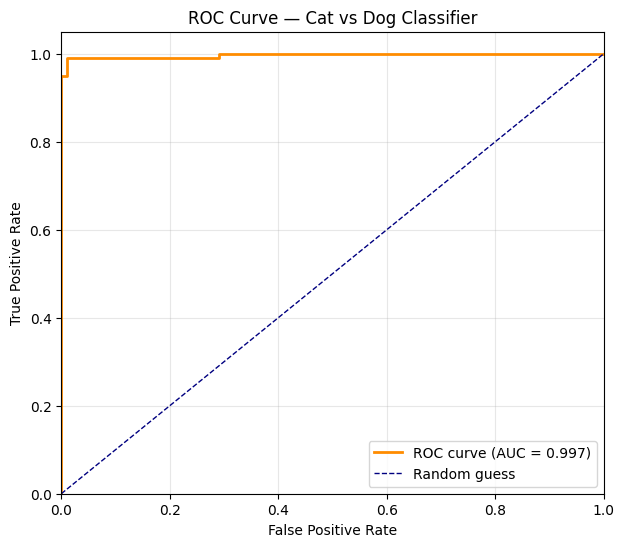

AUC Score: 0.9967


In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Get true labels and predicted probabilities
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0).flatten()
y_pred_probs = model.predict(test_ds).flatten()

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Random guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Cat vs Dog Classifier")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

In [ ]:
import pathlib
import numpy as np

data_dir = pathlib.Path("data/train")
class_names = sorted([item.name for item in data_dir.glob("*") if item.is_dir()])
print(class_names)

all_paths = []
all_labels = []

for label_idx, class_name in enumerate(class_names):
    class_files = list((data_dir / class_name).glob("*"))
    all_paths.extend([str(f) for f in class_files])
    all_labels.extend([label_idx] * len(class_files))

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)
print(f"Total images: {len(all_paths)}")

['cat', 'dog']
Total images: 800


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step
Accuracy:  0.9900
Precision: 0.9900
Recall:    0.9900
F1 Score:  0.9900


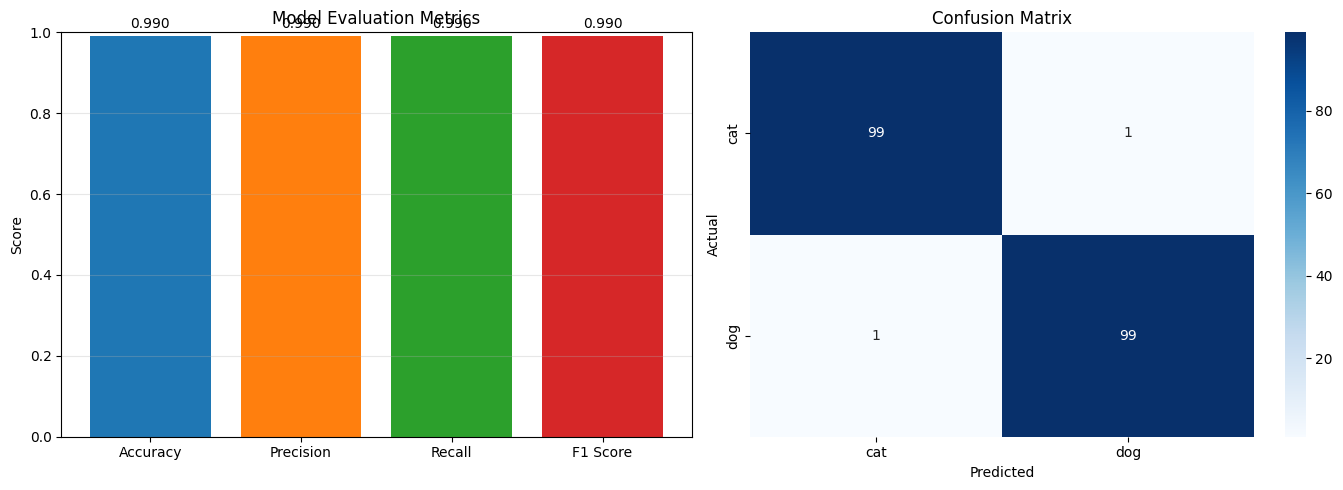

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get true labels and predictions from your already-trained model
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0).flatten()
y_pred_probs = model.predict(test_ds).flatten()
y_pred = (y_pred_probs >= 0.5).astype(int)

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

# --- Plot 1: Metrics bar chart ---
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [acc, prec, rec, f1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(metrics, values, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
axes[0].set_ylim(0, 1.0)
axes[0].set_title("Model Evaluation Metrics")
axes[0].set_ylabel("Score")
axes[0].grid(axis="y", alpha=0.3)

for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}",
                 ha="center", fontsize=10)

# --- Plot 2: Confusion matrix heatmap ---
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

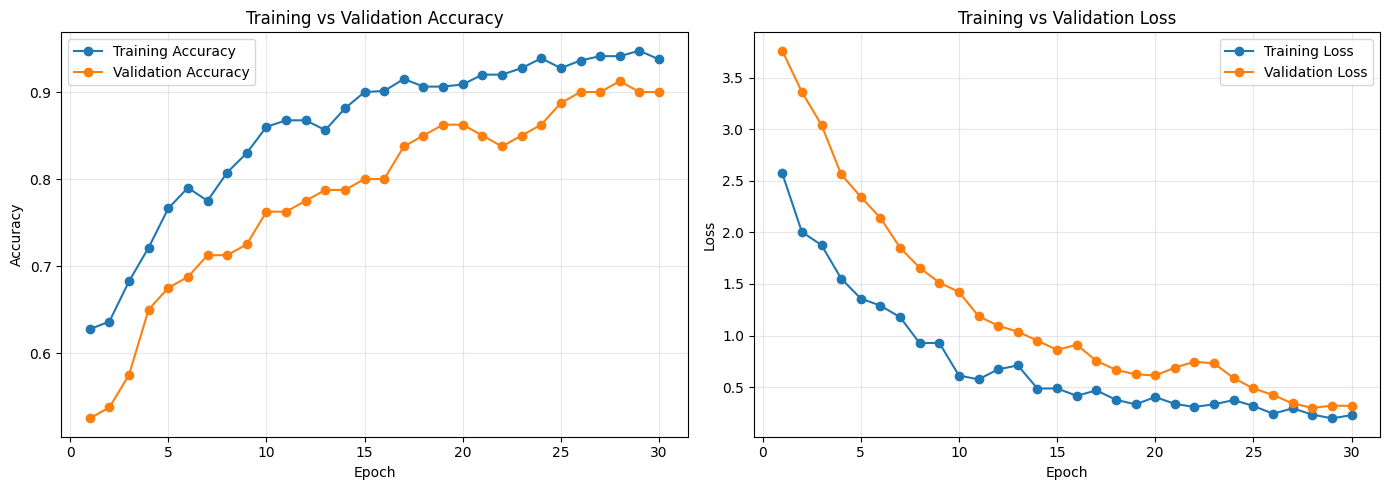

Final training accuracy:   0.9375
Final validation accuracy: 0.9000
Accuracy gap: 0.0375
Gap is small — generalizing reasonably well


In [ ]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(epochs_range, acc, label="Training Accuracy", marker="o")
axes[0].plot(epochs_range, val_acc, label="Validation Accuracy", marker="o")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(epochs_range, loss, label="Training Loss", marker="o")
axes[1].plot(epochs_range, val_loss, label="Validation Loss", marker="o")
axes[1].set_title("Training vs Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Quantify the gap
final_train_acc = acc[-1]
final_val_acc = val_acc[-1]
gap = final_train_acc - final_val_acc
print(f"Final training accuracy:   {final_train_acc:.4f}")
print(f"Final validation accuracy: {final_val_acc:.4f}")
print(f"Accuracy gap: {gap:.4f}")

if gap > 0.10:
    print("⚠️ Significant gap — likely overfitting")
elif gap > 0.05:
    print("Mild gap — worth monitoring")
else:
    print("Gap is small — generalizing reasonably well")

## Save the model

Persists the model currently in this kernel so it can be reused without retraining.
Run this while `model` is still in memory — otherwise use `src/train_eval_save.py`,
which trains and saves from scratch.

In [ ]:
import json
import pathlib

out_dir = pathlib.Path("models")
out_dir.mkdir(exist_ok=True)

model_path = out_dir / "cat_vs_dog_vgg16_notebook.keras"
model.save(model_path)
print(f"Saved -> {model_path}  ({model_path.stat().st_size / 1e6:.1f} MB)")

# Record what the model expects, so whoever loads it later feeds it the right thing.
(out_dir / "cat_vs_dog_vgg16_notebook.json").write_text(json.dumps({
    "img_size": list(img_size),
    "class_names": class_names,          # index 0 -> cat, 1 -> dog
    "output": "single sigmoid = P(dog)",
    "preprocessing": "tensorflow.keras.applications.vgg16.preprocess_input on raw 0-255 RGB",
    "test_metrics": {"accuracy": float(acc), "precision": float(prec),
                     "recall": float(rec), "f1": float(f1)},
}, indent=2))

# Round-trip check: the reloaded model must score exactly the same.
reloaded = tf.keras.models.load_model(model_path)
print("Reloaded test accuracy:", reloaded.evaluate(test_ds, verbose=0)[1])